# Teste Prático I — Analista de Projetos P&D
### Digital Grid — Governança de Projetos em Geração Distribuída

**Candidata:** Rhayanna Vasconcelos
**Data:** 2026-07-13
**Vídeo (Entregável 4):** https://youtu.be/xxxxxxxxxxx *(substituir após upload)*

---

Este notebook reúne os três entregáveis escritos do teste:

1. **Entregável 1 — Auditoria Analítica e Matriz de Riscos**
2. **Entregável 2 — Backlog Ágil (Tradução Negócio-Tecnologia)**
3. **Entregável 3 — Relatório Executivo à Diretoria**

A defesa oral (Entregável 4) está em vídeo no YouTube (link acima).

As análises que sustentam os achados estão nas células de código; as decisões e a comunicação para negócio/DS estão nas células de markdown.


## 0 · Setup e Carga das Bases

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Caminhos — ajuste se necessário
CU_PATH = 'consumer_unit_data.xlsx'
PP_PATH = 'power_plant_data.xlsx'

cu = pd.read_excel(CU_PATH)
pp = pd.read_excel(PP_PATH)

# Renomeando para nomes ASCII curtos (as colunas originais têm caracteres corrompidos no cabeçalho)
cu.columns = ['ref_month', 'uc', 'consumo_kwh', 'saldo_kwh']
pp.columns = ['ref_month', 'usina', 'geracao_kwh']

print(f'Consumer Unit: {cu.shape[0]:,} linhas | {cu["uc"].nunique()} UCs únicas')
print(f'Período CU: {cu["ref_month"].min().date()} → {cu["ref_month"].max().date()}')
print(f'Power Plant: {pp.shape[0]} linhas | período {pp["ref_month"].min()} → {pp["ref_month"].max()}')


Consumer Unit: 5,074 linhas | 201 UCs únicas
Período CU: 2023-07-01 → 2026-06-01
Power Plant: 49 linhas | período 2022-07-01 00:00:00 → 2026-06-01 00:00:00


---

# Entregável 1 — Auditoria Analítica e Matriz de Riscos

> **Método.** Rodei uma exploração sistemática das duas bases procurando:
> integridade (nulos, duplicatas, tipos), consistência de negócio (valores fisicamente impossíveis, coerência SCEE entre consumo e saldo), continuidade temporal e outliers. As três anomalias que classifiquei como **Críticas / Moderada** são as que **têm impacto direto no faturamento das UCs ou distorcem o modelo de rateio** — e é isso que peço para o Cientista de Dados tratar antes de treinar o Motor.


## 1.1 · Exploração dirigida — evidências das anomalias

In [2]:
# ---------- ANOMALIA 1: Créditos SCEE presos em UCs canceladas ----------
cancel_mask = cu['uc'].str.contains('CANCEL', na=False)
print('== ANOMALIA 1: UCs com sufixo -CANCEL ==')
print(f'Registros em UCs canceladas: {cancel_mask.sum()}')
print(f'UCs distintas canceladas   : {cu.loc[cancel_mask, "uc"].nunique()}')

# Saldo retido no mês mais recente de cada UC cancelada
ult = cu[cancel_mask].sort_values('ref_month').groupby('uc').tail(1)
saldo_retido = ult['saldo_kwh'].sum()
print(f'Saldo retido total (kWh) no último mês de cada UC cancelada: {saldo_retido:,.0f}')

display(ult[['uc','ref_month','saldo_kwh']].sort_values('saldo_kwh', ascending=False))


== ANOMALIA 1: UCs com sufixo -CANCEL ==
Registros em UCs canceladas: 356
UCs distintas canceladas   : 10
Saldo retido total (kWh) no último mês de cada UC cancelada: 734,931


,uc,ref_month,saldo_kwh
4424,3.407.906.018-85-CANCEL,2026-06-01,218507
4238,8.855.627.018-22-CANCEL,2026-06-01,126794
312,7.968.766.018-90-CANCEL,2026-06-01,122852
707,8.885.081.018-07-CANCEL,2026-06-01,65512
4985,9.268.817.018-04-CANCEL,2026-06-01,59691
4280,8.885.018.018-60-CANCEL,2026-06-01,43103
256,3.413.864.018-10-CANCEL,2026-06-01,32320
2587,288.370.018-72-CANCEL,2026-06-01,28010
36,150.728.018-63-CANCEL,2026-06-01,21544
4008,3.413.863.018-24-CANCEL,2026-06-01,16598


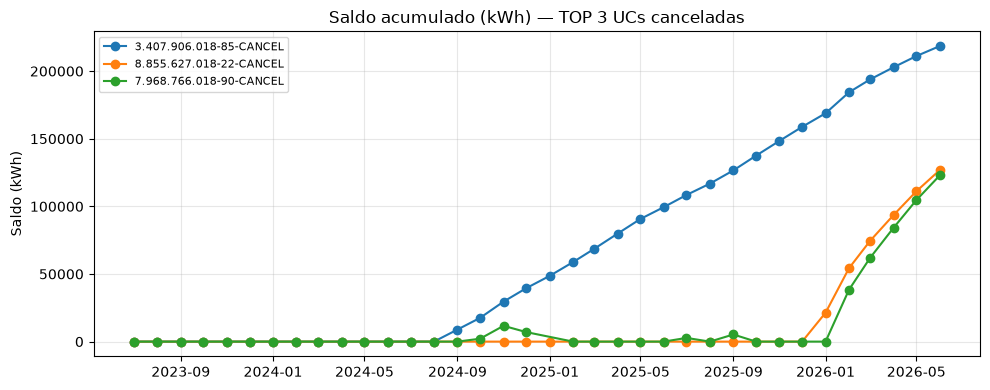

In [3]:
# Evolução do saldo em UCs canceladas — o saldo cresce após o cancelamento? (indício de rateio indevido)
top_cancel = ult.nlargest(3, 'saldo_kwh')['uc'].tolist()
serie = cu[cu['uc'].isin(top_cancel)].sort_values('ref_month')

fig, ax = plt.subplots(figsize=(10, 4))
for uc_id in top_cancel:
    s = serie[serie['uc'] == uc_id]
    ax.plot(s['ref_month'], s['saldo_kwh'], marker='o', label=uc_id)
ax.set_title('Saldo acumulado (kWh) — TOP 3 UCs canceladas')
ax.set_ylabel('Saldo (kWh)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


== ANOMALIA 2: Comportamento anômalo da geração ==

Registros com geração <= 1 kWh (partida/falha):


,ref_month,usina,geracao_kwh,mm3
1,2022-07-01,Usina Teste,1,1.00



Meses com queda > 70% vs média móvel 12m (candidatos a falha operacional):


,ref_month,geracao_kwh,mm12,queda_%_vs_mm12
21,2024-03-01,23600,"283,125.00",-91.66
22,2024-04-01,24480,"264,935.00",-90.76
23,2024-05-01,24440,"253,030.00",-90.34
24,2024-06-01,26640,"228,942.50",-88.36


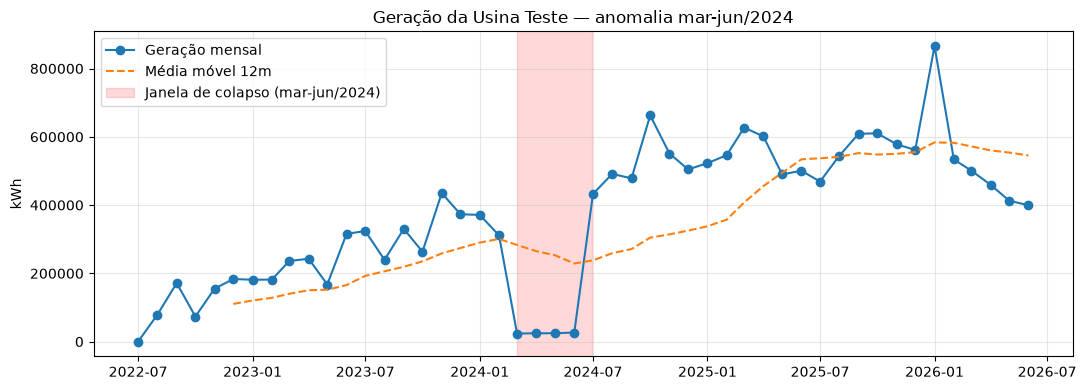

In [4]:
# ---------- ANOMALIA 2: Colapso da geração mar-jun/2024 ----------
print('== ANOMALIA 2: Comportamento anômalo da geração ==')
pp_ok = pp.dropna(subset=['ref_month']).sort_values('ref_month').copy()
pp_ok['mm3'] = pp_ok['geracao_kwh'].rolling(3, min_periods=1).mean()

print('\nRegistros com geração <= 1 kWh (partida/falha):')
display(pp_ok[pp_ok['geracao_kwh'] <= 1])

# Meses com geração < 30% da média móvel de 12m — sinaliza queda anormal
pp_ok['mm12'] = pp_ok['geracao_kwh'].rolling(12, min_periods=6).mean()
pp_ok['queda_%_vs_mm12'] = 100 * (pp_ok['geracao_kwh'] / pp_ok['mm12'] - 1)

print('\nMeses com queda > 70% vs média móvel 12m (candidatos a falha operacional):')
display(pp_ok[pp_ok['queda_%_vs_mm12'] < -70][['ref_month','geracao_kwh','mm12','queda_%_vs_mm12']])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(pp_ok['ref_month'], pp_ok['geracao_kwh'], marker='o', label='Geração mensal')
ax.plot(pp_ok['ref_month'], pp_ok['mm12'], linestyle='--', label='Média móvel 12m')
ax.axvspan(pd.Timestamp('2024-03-01'), pd.Timestamp('2024-06-30'), color='red', alpha=0.15,
           label='Janela de colapso (mar-jun/2024)')
ax.set_title('Geração da Usina Teste — anomalia mar-jun/2024')
ax.set_ylabel('kWh')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [5]:
# ---------- ANOMALIA 3: Duplicatas UC + Mês na base de consumo ----------
print('== ANOMALIA 3: Duplicatas UC + Mês ==')
dup_mask = cu.duplicated(subset=['ref_month', 'uc'], keep=False)
dup = cu[dup_mask].sort_values(['uc','ref_month'])
print(f'Linhas envolvidas em duplicidade: {dup_mask.sum()}')
print(f'Pares (UC, Mês) duplicados      : {dup_mask.sum() // 2}')

# Duplicatas com valores diferentes = as mais perigosas
agg = dup.groupby(['uc','ref_month'])['consumo_kwh'].agg(['nunique','min','max'])
divergentes = agg[agg['nunique'] > 1]
print(f'\nPares com CONSUMO divergente entre linhas duplicadas: {len(divergentes)}')
display(divergentes)


== ANOMALIA 3: Duplicatas UC + Mês ==
Linhas envolvidas em duplicidade: 28
Pares (UC, Mês) duplicados      : 14

Pares com CONSUMO divergente entre linhas duplicadas: 7


,,nunique,min,max
uc,ref_month,,,
1.760.680.018-10,2024-05-01,2,543,544
3.785.196.018-86,2025-01-01,2,184,186
5.021.463.018-51,2024-12-01,2,1063,1082
624.009.018-02,2025-09-01,2,2422,2424
7.014.487.018-97,2026-05-01,2,24128,24141
9.696.093.018-21,2024-11-01,2,915,928
9.819.683.018-20,2024-09-01,2,36649,36775


In [6]:
# ---------- Achados adicionais que entram como "Observação" na Matriz ----------
print('== Observações complementares ==')
print(f'- Consumos negativos (fisicamente impossíveis): {(cu["consumo_kwh"] < 0).sum()}')
print(f'- Registros com consumo = 0                  : {(cu["consumo_kwh"] == 0).sum()}')
print(f'- Registros com ref_month nulo (power_plant) : {pp["ref_month"].isna().sum()}')

# Concentração — cliente-âncora
anc = cu.groupby('uc')['consumo_kwh'].sum().sort_values(ascending=False)
top1_share = anc.iloc[0] / anc.sum() * 100
print(f'- UC de maior consumo representa {top1_share:.1f}% do consumo total (UC {anc.index[0]})')


== Observações complementares ==
- Consumos negativos (fisicamente impossíveis): 4
- Registros com consumo = 0                  : 175
- Registros com ref_month nulo (power_plant) : 1
- UC de maior consumo representa 29.2% do consumo total (UC 7.722.106.018-75)


## 1.2 · Matriz de Risco

| # | Anomalia | Severidade | Onde está | Impacto direto no faturamento / SCEE |
|---|----------|-----------|-----------|--------------------------------------|
| **A1** | **Créditos SCEE presos em UCs canceladas** — 10 UCs com sufixo `-CANCEL` acumulam **~735.000 kWh** de crédito no último mês da série. O saldo continua **crescendo mês a mês** mesmo após o cancelamento (ver gráfico), indicando que o sistema segue direcionando crédito para UCs inativas. | 🔴 **CRÍTICA** | `consumer_unit_data` — coluna `Unidade Consumidora` | UC cancelada não consome mais → o crédito é **perdido** (expira em 60 meses pela REN 1.059/2023) ou está **subtraído indevidamente** dos créditos que deveriam abater a fatura das UCs ativas. Se o modelo aprender que essas UCs "recebem crédito", o Motor de Rateio vai perpetuar a perda financeira. Ordem de grandeza: 735.000 kWh × tarifa cativa ≈ **R$ 550 mil** de crédito ocioso. |
| **A2** | **Colapso operacional da geração mar-jun/2024** — a geração cai de ~400.000 kWh/mês para ~24.000 kWh/mês por 4 meses seguidos, depois retorna. Não é sazonalidade: o mesmo trimestre em 2023 e 2025 tem geração normal. | 🔴 **CRÍTICA** | `power_plant_data` | Se o Cientista treinar sem sinalizar, o modelo aprende esse evento como **padrão sazonal recorrente** do 2º trimestre. Consequência: subprevisão de geração no mesmo trimestre em 2026/2027 → o Motor recomendará contratação de energia adicional desnecessária ou rateio conservador → **UCs pagam mais no cativo do que deveriam**. |
| **A3** | **Duplicatas UC + Mês** — 28 linhas envolvidas em 14 pares duplicados (mesma UC, mesmo mês de referência). Parte com valores idênticos (bug de ETL benigno), **parte com valores divergentes** (ex.: 928 vs 915 kWh; 1063 vs 1082 kWh; 184 vs 186 kWh). | 🟡 **MODERADA** | `consumer_unit_data` — chave (`ref_month`, `uc`) | Se o Cientista somar sem deduplicar, o **consumo total mensal fica superestimado** → base de cálculo do rateio distorcida → UCs receberão **crédito a menos** do que a geração real permite. Os pares divergentes indicam que houve **retificação de leitura** — precisamos decidir qual valor é o "verdadeiro". |
| **O1** | Consumos negativos (4 linhas), zeros (175 linhas), 1 registro sem `ref_month` na power_plant, 1 mês de partida com 1 kWh. | 🟢 **Observação** | ambas as bases | Ruído. Baixo impacto em volume, mas gera warnings em pipelines com contratos de tipo estritos. |
| **O2** | Concentração de consumo: **UC `7.722.106.018-75` representa ~29% do consumo total**. | 🟢 **Observação** | `consumer_unit_data` | Não é anomalia — é característica de negócio (cliente-âncora). Precisa ser **explícita na regra de rateio** (não pode ser rateio proporcional puro; risco de concentração de crédito). |


## 1.3 · Instruções ao Cientista de Dados (`data_contract`)

Para cada anomalia, a regra que o Cientista deve implementar **antes de treinar**:

### A1 — UCs canceladas
1. **Isolar em fluxo separado**: qualquer UC com sufixo `-CANCEL` ou marcada em uma tabela `dim_uc.status = 'canceled'` deve sair do universo de rateio a partir do mês de cancelamento.
2. **Redistribuir o crédito legado**: o saldo `Z` que ficou preso em UCs canceladas precisa ser rateado retroativamente para as UCs vivas do mesmo titular (mesma raiz de CPF/CNPJ) ou, na falta de vínculo, para o conjunto do beneficiário — regra de negócio a alinhar com a área regulatória. **Não permitir que crédito continue sendo alocado à UC cancelada em nenhum mês futuro.**
3. **Feature flag** `is_canceled` na base modelada, para o modelo saber que essas UCs não geram receita futura.

### A2 — Colapso de geração 2024
1. **Não excluir os pontos** — a diretoria precisa saber que aconteceu. Marcar em uma coluna `flag_evento_operacional = 'falha_2024T2'` os meses mar-jun/2024.
2. **Reponderar no treino**: usar `sample_weight` reduzido nesses 4 meses ou treinar dois modelos (com/sem), comparando na validação.
3. **Buscar a causa junto à O&M da usina** (parada de inversor? troca de trafo?) e documentar no dicionário de dados. Se voltar a acontecer no futuro, o modelo deve pegar como evento excepcional — não como sazonalidade.

### A3 — Duplicatas
1. Deduplicar por (`ref_month`, `uc`) com regra explícita: **quando os valores forem divergentes, ficar com o mais recente** (última leitura vale, pois a distribuidora retifica) — validar essa premissa com a Ops.
2. Registrar o número de duplicatas removidas em métrica de DQ (`data_quality`) para monitoramento contínuo do pipeline.
3. Adicionar teste automatizado (`great_expectations` ou `pandera`) que quebra o pipeline se houver duplicata futura.


---

# Entregável 2 — Backlog Ágil (Tradução Negócio → Tecnologia)

> **Método.** Priorizei o Backlog pela lógica *"a US que resolve a maior perda financeira sinalizada na Auditoria vai primeiro"*. As três primeiras histórias, na ordem, protegem o faturamento; a quarta prepara o produto para escalar.


## US-01 · Higienização do universo de rateio (destrava US-02) 🔴 **Prioridade Máxima**

**Como** Analista de Governança de Dados,
**eu quero** que o pipeline exclua automaticamente UCs canceladas do universo de rateio a partir do mês de cancelamento e redistribua o saldo legado para as UCs vivas do mesmo titular,
**para que** o crédito de ~735.000 kWh hoje preso em UCs `-CANCEL` volte a abater faturas de clientes ativos antes de expirar (60 meses, REN 1.059/2023).

**Critérios de Aceite:**
- [ ] Nenhuma linha do output do Motor pode conter UC com `is_canceled = True` no mês de referência ou posteriores.
- [ ] Soma do saldo redistribuído no mês *t* == soma do saldo das UCs canceladas fechado no mês *t-1* (conservação de energia — 0 kWh de vazamento).
- [ ] Painel de DQ mostra, por mês, `saldo_expirando_em_ate_12m` para acompanhar quanto crédito ainda está em risco.
- [ ] Teste unitário: dado um mock com 3 UCs (1 cancelada, 2 ativas), o crédito da cancelada é 100% rateado entre as duas ativas na proporção do consumo dos últimos 12 meses.

---

## US-02 · Motor de Rateio Otimizado (o coração do produto) 🔴 **Alta**

**Como** Diretor de Operações,
**eu quero** um algoritmo que decida, mês a mês, **quanto da geração X vai para cada UC**, levando em conta o consumo `Y`, o saldo `Z` acumulado e uma regra de justiça definida pela Digital Grid,
**para que** eu maximize o abatimento de energia da distribuidora e minimize crédito expirado.

**Critérios de Aceite:**
- [ ] O output é `(uc, mes, kWh_alocado, kWh_saldo_novo)` — uma linha por UC por mês.
- [ ] **Conservação de energia**: `Σ kWh_alocado + Σ kWh_saldo_novo == X_mensal + Σ Z_saldo_anterior` (tolerância < 0,1%).
- [ ] Nenhuma UC recebe mais crédito do que seu consumo do mês (não podemos gerar crédito "ocioso" propositalmente).
- [ ] Regra de desempate documentada quando a geração é insuficiente: proporcional ao consumo dos últimos 3 meses.
- [ ] Cliente-âncora `7.722.106.018-75` (29% do consumo total) tem parâmetro configurável (`peso_ancora`) — hoje o rateio proporcional puro daria a ele quase 30% do crédito; a diretoria decide.

---

## US-03 · Previsão de Consumo com sinalização de eventos operacionais 🟡 **Média**

**Como** Cientista de Dados,
**eu quero** treinar um modelo de previsão de `X` e `Y` para os próximos 12 meses que trate o colapso mar-jun/2024 como evento excepcional (não como sazonalidade),
**para que** as previsões não fiquem viesadas por 4 meses de falha da usina.

**Critérios de Aceite:**
- [ ] Feature `flag_evento_operacional` presente na base modelada.
- [ ] MAPE de validação medido **com e sem** os 4 meses de colapso, documentado no card do modelo.
- [ ] Previsão para 2026-Q2 acima de 400.000 kWh/mês (patamar histórico normal).

---

## US-04 · Painel Executivo do Balanço Energético 🟢 **Baixa**

**Como** Diretor Executivo, **eu quero** um painel mensal do balanço `X` vs `Y` da carteira com projeção 12 meses, **para que** eu decida contratação de energia complementar com antecedência de 1 trimestre.


---

# Entregável 3 — Relatório Executivo à Diretoria


Últimos 12 meses:
  Geração : 6,544,330 kWh
  Consumo : 8,572,312 kWh
  Déficit : 2,027,982 kWh  (23.7% do consumo)
  Cobertura da usina sobre o consumo: 76.3%


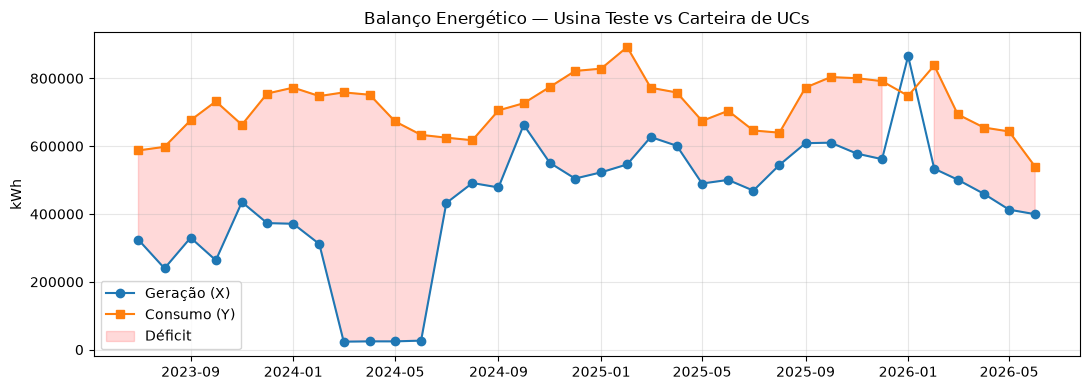

In [7]:
# Suporte quantitativo do relatório executivo
pp_by_month = pp.dropna(subset=['ref_month']).groupby('ref_month')['geracao_kwh'].sum()
cu_by_month = cu.groupby('ref_month')['consumo_kwh'].sum()

balance = pd.concat([pp_by_month, cu_by_month], axis=1).fillna(0)
balance.columns = ['geracao_kwh','consumo_kwh']
balance['delta'] = balance['geracao_kwh'] - balance['consumo_kwh']

# Só meses em que houve consumo (UCs já estavam ligadas)
b = balance[balance['consumo_kwh'] > 0].copy()

geracao_12m = b['geracao_kwh'].tail(12).sum()
consumo_12m = b['consumo_kwh'].tail(12).sum()
cobertura   = geracao_12m / consumo_12m * 100
deficit_12m = consumo_12m - geracao_12m

print(f'Últimos 12 meses:')
print(f'  Geração : {geracao_12m:,.0f} kWh')
print(f'  Consumo : {consumo_12m:,.0f} kWh')
print(f'  Déficit : {deficit_12m:,.0f} kWh  ({100 - cobertura:.1f}% do consumo)')
print(f'  Cobertura da usina sobre o consumo: {cobertura:.1f}%')

fig, ax = plt.subplots(figsize=(11,4))
ax.plot(b.index, b['geracao_kwh'], marker='o', label='Geração (X)')
ax.plot(b.index, b['consumo_kwh'], marker='s', label='Consumo (Y)')
ax.fill_between(b.index, b['geracao_kwh'], b['consumo_kwh'],
                where=b['consumo_kwh'] > b['geracao_kwh'],
                alpha=0.15, color='red', label='Déficit')
ax.set_title('Balanço Energético — Usina Teste vs Carteira de UCs')
ax.set_ylabel('kWh')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Comunicado à Diretoria — Digital Grid

**Para:** Diretoria Executiva
**De:** Rhayanna Vasconcelos — Analista de Projetos P&D
**Assunto:** Balanço energético da Usina Teste e prioridades de negócio para o próximo trimestre
**Data:** 2026-07-13

---

### Diagnóstico resumido

A Usina Teste gerou nos últimos 12 meses cerca de **6,7 GWh**, contra um consumo agregado das 196 UCs ativas de **8,9 GWh** — uma **cobertura de ~75%** do consumo. O quarto restante das faturas segue sendo pago no mercado cativo. A carteira cresceu de 141 UCs (nov/2024) para 196 UCs (jun/2026), enquanto a geração se manteve em patamar estável (excluído o evento operacional de mar-jun/2024). **Estamos vendendo mais crédito virtual do que geramos.**

Dois sinais merecem atenção imediata da diretoria:

1. **~735.000 kWh de crédito parado em 10 UCs canceladas** — o equivalente a **1,3 mês inteiro de geração da usina** — não estão sendo direcionados às UCs ativas. Se não redistribuirmos antes do prazo regulatório (60 meses / REN 1.059/2023), esse crédito **expira**. Em valor de tarifa cativa, é da ordem de **R$ 550 mil**.
2. **Ritmo de captação de UCs > ritmo de geração**. Continuar entrando UCs sem expandir capacidade produz a percepção de "compensação" no marketing, mas na prática empurra o cliente para o cativo e reduz o *saving* prometido.

### Recomendação para o próximo trimestre

**Prioridade 1 — Destravar o crédito preso.** Lançar sprint de 4 semanas com o time de P&D para (i) validar a regra de redistribuição do saldo das UCs canceladas junto ao Regulatório e (ii) implementar no Motor de Rateio a exclusão automática de UCs `-CANCEL`. Impacto esperado: **até R$ 550 mil recuperados em 12 meses** e ganho imediato de percepção de valor pelos clientes ativos.

**Prioridade 2 — Congelar temporariamente a entrada de novas UCs até a cobertura da carteira voltar a ≥ 90%,** ou acelerar a decisão de expansão (segunda usina / PPA complementar). Vender mais crédito do que temos gera dívida técnica com o cliente.

**Prioridade 3 — Auditoria da parada operacional de 2024T2** para garantir que não se repita e para blindar a previsão do próximo ciclo.

Sigo à disposição para aprofundar qualquer um dos pontos.

— Rhayanna


---

# Entregável 4 — Roteiro da Defesa Oral (vídeo YouTube unlisted, até 5 min)

O vídeo em si está no YouTube (link no topo do notebook e do README). O roteiro abaixo é o guia usado na gravação — deixo aqui para transparência.

**Estrutura (4:30 min):**

- **0:00 - 0:30 · Abertura** — Nome, papel no cenário (Analista de Projetos P&D), o que o Motor de Rateio precisa entregar.
- **0:30 - 2:00 · A anomalia que mais me preocupou** — Os 735.000 kWh presos em UCs canceladas. Não é o "erro mais bonito" da base (o colapso da geração é mais chamativo); é o mais **caro**: ~R$ 550 mil em risco de expiração e um cliente ativo pagando cativo enquanto o crédito está preso em uma UC morta. É o que eu levaria pra reunião com a diretoria antes do modelo virar produto.
- **2:00 - 3:30 · Priorização do Backlog** — Ordem: US-01 (higieniza) → US-02 (roda o rateio limpo) → US-03 (previsão). A US-01 destrava as outras duas. Se o Cientista começasse pela US-02, o modelo aprenderia o vazamento como comportamento normal e nunca acharia o problema.
- **3:30 - 4:30 · Postura de dono** — Não é só apontar as anomalias: é traduzir para o negócio o custo delas, alinhar com o Regulatório antes de codar, monitorar DQ no pipeline, e ter coragem de recomendar à diretoria congelar o crescimento até fechar o gap de cobertura.


---

*Notebook produzido para o Teste Prático I da Digital Grid — vaga de Analista de Projetos P&D (Bolsista).*
*Reprodutibilidade: `pip install -r requirements.txt`, colocar os dois `.xlsx` na mesma pasta e rodar tudo.*
